### Figure 1 
subplot of 
- (a) hydrophone acoustic signal to obtain critical shear stress
- (b) example of Aich (2014) hysteresis calculations
- (c) hydrograph specific transport metrics example 

Note: Hex codes for viridis colors: 
- #440154 (Dark Purple / Violet)
- #3b528b (Deep Blue)
- #21918c (Teal)
- #5ec962 (Light Green)
- #fde725 (Yellow)

In [3]:
import numpy as np
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# import data 
shear_stress = pd.read_csv('../../data/shear_stress/average_total_shear_stress_corrected.csv', parse_dates=['datetime'], index_col='datetime')
dmax = pd.read_csv('st2_hydrophone_dmax.csv', parse_dates=['Time'], index_col='Time')
sonde_downstream = pd.read_csv('../../data/sonde_data/sonde_down_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
sonde_downstream = sonde_downstream.groupby(level=0).mean(numeric_only=True)


shear_stress = shear_stress.resample('1min').interpolate()
dmax = dmax.join(shear_stress, how="left")
sonde_downstream = sonde_downstream.join(shear_stress['shear_stress'], how="left")
# modify the specific dates 
dmax = dmax.loc['2022-08-03 13:00:00':'2022-08-03 21:00:00']
sonde_downstream = sonde_downstream.loc['2021-07-23 12:30:00':'2021-07-28 11:15']


### (a) hydrophone acoustic signal to obtain critical shear stress

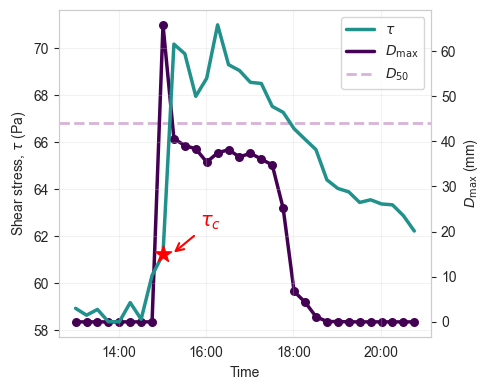

In [7]:
teal = '#21918c'
purple = "#440154"

D50 = 44  # mm
sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(5, 4))

# shear stress line
ax1.plot(dmax.index, dmax["shear_stress"], color=teal, lw=2.5, label=r"$\tau$", zorder=5)
ax1.set_ylabel(r"Shear stress, $\tau$ (Pa)")
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
# Dmax line
ax2.plot(dmax.index, dmax["Dmax (mm)"], color=purple, lw=2.5, label=r"$D_{\max}$", zorder=5)
ax2.scatter(dmax.index, dmax["Dmax (mm)"], color=purple, s=30, zorder=5)
ax2.set_ylabel(r"$D_{\max}$ (mm)")
ax2.tick_params(axis="y")
# horizontal line showing D50
ax2.axhline(D50, color="purple", ls="--", lw=2, label=r"$D_{50}$", alpha=0.3)

# find the index of the first Dmax that exceeds D50
idx = dmax[dmax["Dmax (mm)"] >= D50].index[0]
tau_c = dmax.loc[idx, "shear_stress"]
ax1.scatter(idx, tau_c, color="red", s=150, zorder=20, marker="*")
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)

# annotate tau_c
ax1.annotate(r"$\tau_c$", xy=(idx+pd.Timedelta(hours=0.2), tau_c), xytext=(20,20), textcoords="offset points", color="red",
    fontsize=14, arrowprops=dict(arrowstyle="->", color="red", lw=1.5), zorder=100)
xmin = dmax.index.min()
xmax = idx
# horizontal line showing tauc
#ax1.hlines(tau_c, xmin=dmax.index[0], xmax=idx, color="red", linestyle="--", linewidth=2, zorder=10)
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.25)
ax2.grid(False)

# combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

(b) 

In [5]:
sonde_downstream

,Turbidity FNU,fDOM RFU,shear_stress
DateTime,,,
2021-07-23 12:30:00,1.810,14.548,63.685701
2021-07-23 12:45:00,2.954,15.044,63.900036
2021-07-23 13:00:00,4.632,15.688,64.811895
2021-07-23 13:15:00,5.952,16.680,66.239718
2021-07-23 13:19:00,6.756,17.832,66.549392
...,...,...,...
2021-07-28 10:15:00,2.642,17.894,66.145617
2021-07-28 10:30:00,2.636,17.922,66.020200
2021-07-28 10:45:00,2.628,17.914,66.020200


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def normalize_data(df, tau_col, constituent_col):
    pair = df[[tau_col, constituent_col]].copy()
    pair[tau_col] = pd.to_numeric(pair[tau_col], errors="coerce")
    pair[constituent_col] = pd.to_numeric(pair[constituent_col], errors="coerce")
    pair = pair.dropna(subset=[tau_col, constituent_col]).sort_index()
    pair = pair.reset_index(drop=True)

    if pair.empty:
        return None

    tau_max = pair[tau_col].max()
    cn_max = pair[constituent_col].max()

    if pd.isna(tau_max) or pd.isna(cn_max) or tau_max == 0 or cn_max == 0:
        return None

    pair["tau_n"] = pair[tau_col] / tau_max
    pair["cn"] = pair[constituent_col] / cn_max
    return pair

def split_hydrograph(norm_df):
    if norm_df.empty:
        return None, None, None

    peak_pos = norm_df["tau_n"].to_numpy().argmax()
    rise = norm_df.iloc[:peak_pos + 1][["tau_n", "cn"]]
    fall = norm_df.iloc[peak_pos + 1:][["tau_n", "cn"]]

    return rise, fall, peak_pos


def reference_line(norm_df, peak_pos):
    peak_row = norm_df.iloc[peak_pos]
    last_row = norm_df.iloc[-1]

    x1 = peak_row["tau_n"]
    y1 = peak_row["cn"]
    x2 = last_row["tau_n"]
    y2 = last_row["cn"]

    A = y1 - y2
    B = x2 - x1
    C = x1 * y2 - x2 * y1
    return A, B, C


def distance_from_line(df_xy, A, B, C):
    return (A * df_xy["tau_n"] + B * df_xy["cn"] + C) / np.sqrt(A**2 + B**2)


def projection_to_line(x0, y0, A, B, C):
    d = (A * x0 + B * y0 + C) / (A**2 + B**2)
    x_proj = x0 - A * d
    y_proj = y0 - B * d
    return x_proj, y_proj


def calculate_aich_HI(df, tau_col, constituent_col, storm_name):
    norm_df = normalize_data(df, tau_col, constituent_col)

    if norm_df is None or len(norm_df) < 3:
        print(f"Not enough paired data to calculate AICH HI for storm {storm_name}")
        return None

    rise, fall, peak_pos = split_hydrograph(norm_df)

    if rise is None or fall is None or rise.empty or fall.empty:
        print(f"Not enough data points to calculate AICH HI for storm {storm_name}")
        return None

    A, B, C = reference_line(norm_df, peak_pos)

    rise_dist = -distance_from_line(rise, A, B, C)
    fall_dist = distance_from_line(fall, A, B, C)

    if rise_dist.empty or fall_dist.empty:
        print(f"Not enough data points to calculate AICH HI for storm {storm_name}")
        return None

    rise_idx = rise_dist.abs().to_numpy().argmax()
    fall_idx = fall_dist.abs().to_numpy().argmax()

    Drise = rise_dist.iloc[rise_idx]
    Dfall = fall_dist.iloc[fall_idx]
    HI = Drise + Dfall

    results = {
        "HI": HI,
        "Drise": Drise,
        "Dfall": Dfall,
        "storm_name": storm_name,
        "peak tau": norm_df.iloc[peak_pos]["tau_n"],
        "peak constituent": norm_df.iloc[peak_pos]["cn"],
        "rise": rise,
        "fall": fall,
        "A": A,
        "B": B,
        "C": C,
        "Drise_point": (rise.iloc[rise_idx]["tau_n"], rise.iloc[rise_idx]["cn"]),
        "Dfall_point": (fall.iloc[fall_idx]["tau_n"], fall.iloc[fall_idx]["cn"]),
        "norm_df": norm_df,
    }
    return results

In [48]:
def plot_aich_hysteresis(results, xlabel=r"Normalized Shear Stress ($\tau_n$)", ylabel="Normalized Constituent ($C_n$)", save=False, show=True):

    norm_df = results["norm_df"]
    rise = results["rise"]
    fall = results["fall"]

    A = results["A"]
    B = results["B"]
    C = results["C"]

    Drise = results["Drise"]
    Dfall = results["Dfall"]
    HI = results["HI"]
    xr, yr = results["Drise_point"]
    xf, yf = results["Dfall_point"]

    xr_proj, yr_proj = projection_to_line(xr, yr, A, B, C)
    xf_proj, yf_proj = projection_to_line(xf, yf, A, B, C)

    xmin = min(norm_df["tau_n"].min(), xr_proj, xf_proj) - 0.05
    xmax = max(norm_df["tau_n"].max(), xr_proj, xf_proj) + 0.05
    xline = np.linspace(xmin, xmax, 200)
    yline = -(A * xline + C) / B

    rise_color = "#24918D"       # teal
    fall_color = "#440154"       # dark purple
    reference_color = "gray"

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(norm_df["tau_n"], norm_df["cn"], color="0.35", linewidth=2, alpha=0.65, zorder=1)
    ax.plot(rise["tau_n"], rise["cn"], color=rise_color, linewidth=2.5, zorder=3)
    ax.scatter(rise["tau_n"], rise["cn"], color=rise_color, s=55, label="Rising limb", zorder=4)
    ax.plot(fall["tau_n"], fall["cn"], color=fall_color, linewidth=2.5, zorder=3)
    ax.scatter(fall["tau_n"], fall["cn"], color=fall_color, s=55, label="Falling limb", zorder=4)
    # reference line
    ax.plot(xline, yline, linestyle="--", color=reference_color, linewidth=2.5, label="Reference line", zorder=2)

    # Drise measurement
    ax.plot([xr, xr_proj], [yr, yr_proj], linestyle="--", color=rise_color, linewidth=2.5, zorder=5)
    ax.scatter([xr, xr_proj], [yr, yr_proj], color=rise_color, s=70, zorder=6)
    # midpoint of Drise segment
    xr_mid = (xr + xr_proj) / 2
    yr_mid = (yr + yr_proj) / 2

    ax.annotate(
        r"$D_{\mathrm{rise}}$",
        xy=(xr_mid, yr_mid),
        xytext=(20, 12),
        textcoords="offset points",
        color=rise_color,
        fontsize=12,
        fontweight="bold",
        ha="right",
        va="bottom",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=8
    )
    # Dfall measurement
    ax.plot([xf, xf_proj], [yf, yf_proj], linestyle="--", color=fall_color, linewidth=2.5, zorder=5)
    ax.scatter([xf, xf_proj], [yf, yf_proj], color=fall_color, s=70, zorder=6)
    # Midpoint of Dfall segment
    xf_mid = (xf + xf_proj) / 2
    yf_mid = (yf + yf_proj) / 2

    ax.annotate(
        r"$D_{\mathrm{fall}}$",
        xy=(xf_mid, yf_mid),
        xytext=(10, -12),
        textcoords="offset points",
        color=fall_color,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=8
    )

    # Axis limits with equal scaling
    geom_x = np.r_[norm_df["tau_n"].to_numpy(), xr, xr_proj, xf, xf_proj]
    geom_y = np.r_[norm_df["cn"].to_numpy(), yr, yr_proj, yf, yf_proj]

    x_min, x_max = geom_x.min(), geom_x.max()
    y_min, y_max = geom_y.min(), geom_y.max()

    x_span = x_max - x_min
    y_span = y_max - y_min
    span = max(x_span, y_span)

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)

    pad = 0.08 * span
    ax.set_xlim(
        x_mid - span / 2 - pad,
        x_mid + span / 2 + pad
    )
    ax.set_ylim(
        y_mid - span / 2 - pad,
        y_mid + span / 2 + pad
    )
    ax.set_aspect("equal", adjustable="box")

    # formatting
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    # Put HI in a small box rather than the title
    summary_text = (
        rf"$D_{{\mathrm{{rise}}}}={Drise:.2f}$" "\n"
        rf"$D_{{\mathrm{{fall}}}}={Dfall:.2f}$" "\n"
        rf"$HI={HI:.2f}$"
    )

    ax.text(
        0.70,
        0.97,
        summary_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        linespacing=1.4,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="none",
            edgecolor="1",
            alpha=0.9
        ),
        zorder=10
    )

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, loc="lower right")
    fig.tight_layout()
    plt.show()

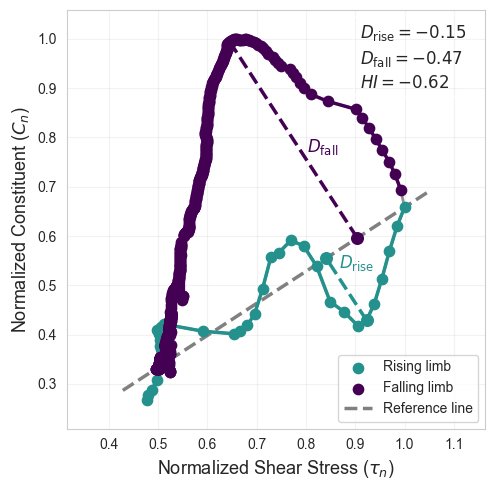

In [49]:
results_fdom = calculate_aich_HI(df=sonde_downstream, tau_col="shear_stress",
    constituent_col="fDOM RFU", storm_name="July 2021 event")

plot_aich_hysteresis(results=results_fdom)